# Maternal Health Risk Prediction

Kehamilan adalah perjalanan yang mendalam dan transformatif dalam kehidupan seorang wanita, penuh dengan kegembiraan dan harapan. Namun, kehamilan juga disertai dengan berbagai risiko dan tantangan, baik bagi ibu yang sedang mengandung maupun bagi anak yang belum lahir. Memprediksi dan mengelola risiko ini sangat penting untuk memastikan kehamilan yang aman dan sehat. Di sinilah bidang data science memainkan peran penting.

Proyek data science ini bertujuan untuk memanfaatkan kekuatan data science dan machine learning guna meningkatkan perawatan prenatal dan kesejahteraan wanita hamil. Proyek ini berupaya mengembangkan model prediktif yang dapat menilai faktor-faktor risiko yang terkait dengan kehamilan.

Data untuk proyek ini diambil dari berbagai sumber, seperti rumah sakit, klinik komunitas, dan pusat kesehatan ibu melalui sistem pemantauan risiko berbasis IoT.

## Kolom dalam Dataset

- **Age**: Usia dalam tahun saat seorang wanita hamil.
- **SystolicBP**: Nilai atas dari tekanan darah dalam mmHg, merupakan atribut penting selama kehamilan.
- **DiastolicBP**: Nilai bawah dari tekanan darah dalam mmHg, juga merupakan atribut penting selama kehamilan.
- **BS**: Kadar glukosa darah dalam satuan konsentrasi molar, mmol/L.
- **HeartRate**: Detak jantung istirahat normal dalam denyut per menit.
- **RiskLevel**: Tingkat intensitas risiko yang diprediksi selama kehamilan berdasarkan atribut-atribut sebelumnya.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

import scipy.stats as stats 
from scipy.stats import chi2_contingency, boxcox

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm 

## Read dan Understanding Data

In [2]:
data = pd.read_csv("dataset/Maternal Health Risk Data Set.csv")

In [3]:
data.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [5]:
data[data.duplicated(keep='first')]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
67,19,120,80,7.0,98.0,70,mid risk
72,19,120,80,7.0,98.0,70,mid risk
97,19,120,80,7.0,98.0,70,mid risk
106,50,140,90,15.0,98.0,90,high risk
107,25,140,100,6.8,98.0,80,high risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


Lebih dari setengah baris dalam dataset merupakan duplikat! Hal ini dapat memengaruhi hasil analisis kita, sehingga kita perlu menghapus baris-baris duplikat tersebut.

Untuk melihat informasi statistik lebih lanjut tentang dataset, kita dapat menggunakan metode `.describe()`.


In [6]:
data.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


Mari kita eksplorasi observasi dengan usia di atas 60 tahun dan di atas 13 tahun.

In [7]:
data[data.Age > 60]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
114,63,140,90,15.0,98.0,90,high risk
313,62,120,80,6.9,98.0,66,low risk
322,65,90,60,6.9,98.0,70,low risk
326,66,85,60,6.9,98.0,86,low risk
338,70,85,60,6.9,102.0,70,low risk
339,65,120,90,6.9,103.0,76,low risk
435,65,130,80,15.0,98.0,86,high risk
502,63,140,90,15.0,98.0,90,high risk


In [8]:
len(data[data.Age < 13])

39

## Observasi dari Eksplorasi Data Awal

- Kita memiliki 1014 entri serta 7 fitur.
- Lima kolom pertama disimpan dalam bentuk integer dan float, sedangkan tipe data dari kolom terakhir (RiskLevel) adalah object, yang perlu dikonversi menjadi nilai numerik untuk keperluan machine learning.
- **RiskLevel** akan menjadi target atau variabel respon kita, dan fitur lainnya akan menjadi variabel prediktor.
- Tidak ada nilai null di dalam dataset.
- Terdapat banyak baris duplikat.
- Rentang usia berkisar dari 10 hingga 70 tahun. Meskipun jarang terjadi, tetap memungkinkan bagi beberapa anak perempuan untuk hamil pada usia 10 tahun, begitu juga dengan wanita berusia 70 tahun. Sebagai contoh, berikut adalah data tentang angka kelahiran untuk anak perempuan usia 10–14 tahun di Amerika Serikat.
- Penting untuk dicatat bahwa nilai minimum dari semua kolom lebih besar dari 0.
- Terdapat observasi dengan heart rate sebesar 7, yang tidak masuk akal. Kita perlu memperbaikinya.

## Data Cleaning

In [9]:
df = data.copy()

### Drop Duplicate

In [10]:
df = df.drop_duplicates().reset_index(drop=True)

In [11]:
df.shape

(452, 7)

#### Memperbaiki kolom HeartBeat 

Terdapat sebuah observasi dengan nilai heart rate sebesar 7, yang tidak masuk akal. Kemungkinan besar, ini adalah kesalahan saat entri data. Namun, kita tidak mengetahui nilai yang sebenarnya — bisa saja seharusnya 70, 67, atau 77. Oleh karena itu, kita akan menggantinya dengan modus (nilai yang paling sering muncul) dari kolom tersebut.


In [12]:
df.HeartRate.mode()

0    70
Name: HeartRate, dtype: int64

In [13]:
df.loc[df.HeartRate == 7, "HeartRate"] = 70

## Feature Encoding untuk categorical variable

In [14]:
df.RiskLevel.unique()

array(['high risk', 'low risk', 'mid risk'], dtype=object)

Tipe kolom HeartRate adalah ordinal, dengan kata lain, nilainya berada dalam kategori yang berurutan. Untuk itu, kita dapat melakukan label encoding, di mana setiap nilai akan secara manual dipetakan ke kunci yang sesuai dengan menggunakan fungsi `replace()`.


In [15]:
df.replace({"high risk":2, "mid risk":1, "low risk":0}, inplace=True)
df.head()

C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_23340\247815498.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"high risk":2, "mid risk":1, "low risk":0}, inplace=True)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


## Exporing the Outliers

Dalam statistik, **outlier** adalah titik observasi yang jauh dari observasi lainnya. Outlier dapat disebabkan oleh kesalahan dalam pengumpulan atau pencatatan data, atau karena variabilitas tinggi secara alami pada titik data. Cara mengatasi outlier sangat bergantung pada data kita atau jenis analisis yang akan dilakukan. Outlier dapat secara signifikan memengaruhi model kita dan juga bisa menjadi sumber informasi yang berharga, memberikan wawasan tentang perilaku tertentu.

Ada banyak cara untuk menemukan outlier dalam data kita. Kita bisa melakukan analisis univariat (menggunakan analisis satu variabel) atau analisis multivariat (menggunakan dua atau lebih variabel). Salah satu cara paling sederhana untuk mendeteksi outlier adalah dengan memeriksa data secara visual, dengan membuat **box plot**.


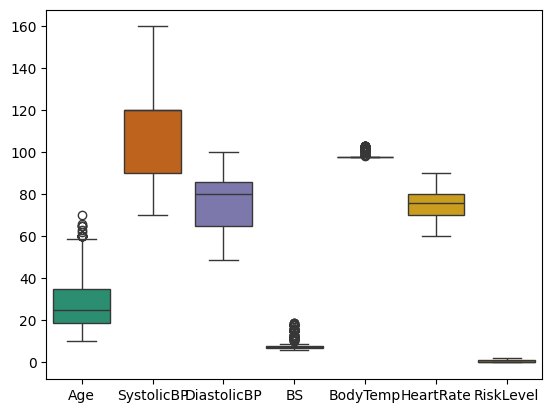

In [16]:
sns.set_palette("Dark2")

sns.boxplot(df);

Dari **boxplot** sederhana dari seluruh dataframe di atas, kita dapat menemukan kolom-kolom yang memiliki outlier untuk pemeriksaan lebih lanjut. Selain itu, kita juga dapat melihat bahwa variabel-variabel kita memiliki skala yang berbeda, dan nantinya kita mungkin perlu melakukan **feature scaling**.


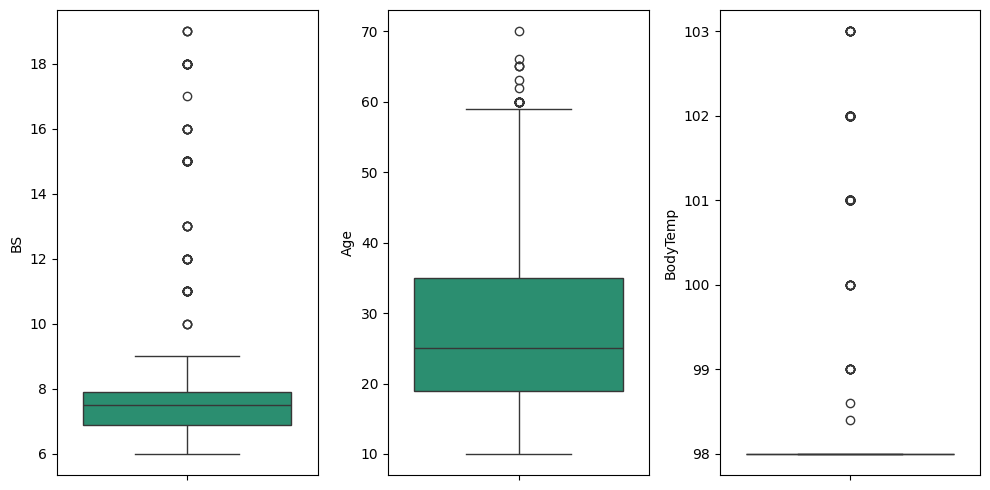

In [17]:
plt.figure(figsize=(10, 5))
plt.subplot(1,3,1)
sns.boxplot(y = 'BS', data = df)
plt.subplot(1,3,2)
sns.boxplot(y = 'Age', data = df)
plt.subplot(1,3,3)
sns.boxplot(y = 'BodyTemp', data = df)

plt.tight_layout()
plt.show();

Seperti yang dapat kita lihat dari plot ini, terdapat beberapa titik yang terletak di luar area **box plot** dan sangat menyimpang dari sisa populasi. Apakah kita akan menghapus atau mempertahankan titik-titik tersebut sangat bergantung pada pemahaman kita tentang data dan jenis analisis yang akan dilakukan. Dalam kasus ini, titik-titik yang berada di luar box plot kita mungkin merupakan titik data yang benar-benar valid dan tidak perlu dihapus.


## Exploratory Data Analysis (EDA)

### Univariate Analysis dan Bivariate Analysis

Age

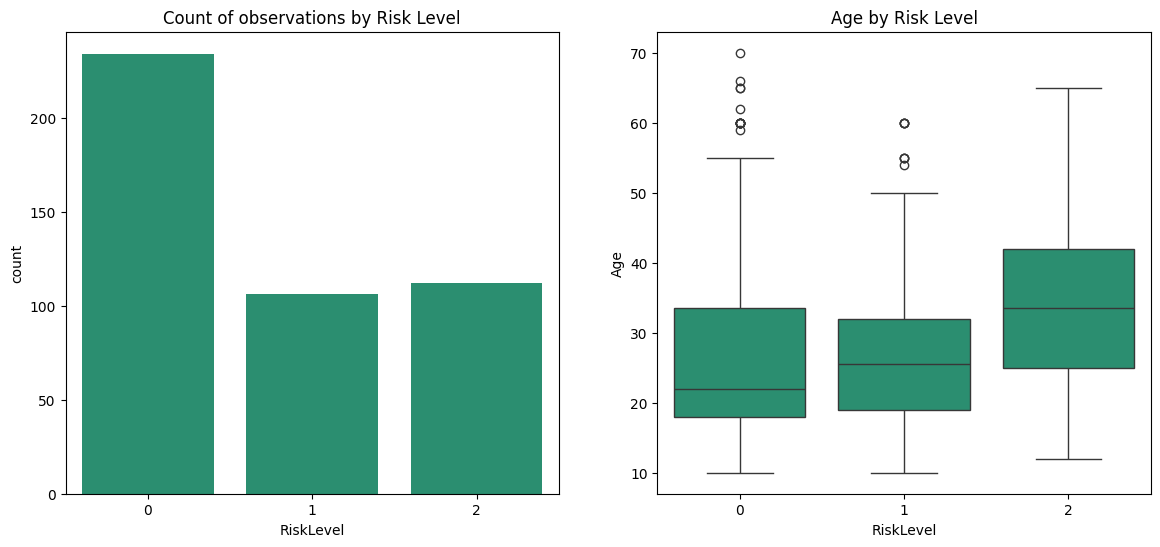

In [18]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(14,6))

sns.countplot(ax=axes[0], x=df.RiskLevel)
axes[0].set_title("Count of observations by Risk Level")

sns.boxplot(ax=axes[1], x=df.RiskLevel, y=df.Age)
axes[1].set_title("Age by Risk Level");

Blood Glucose level

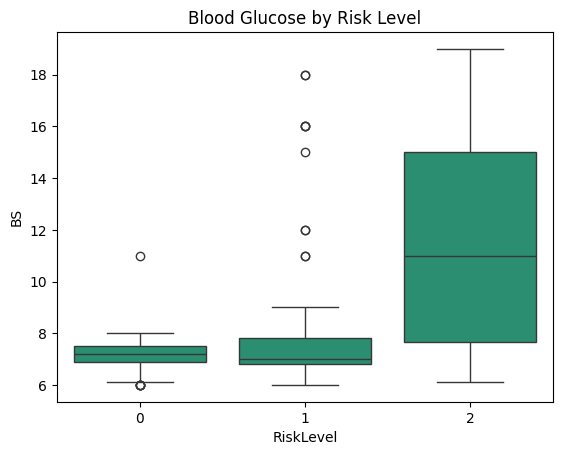

In [19]:
sns.boxplot(x=df.RiskLevel, y=df.BS).set_title("Blood Glucose by Risk Level");

Blood Pressure

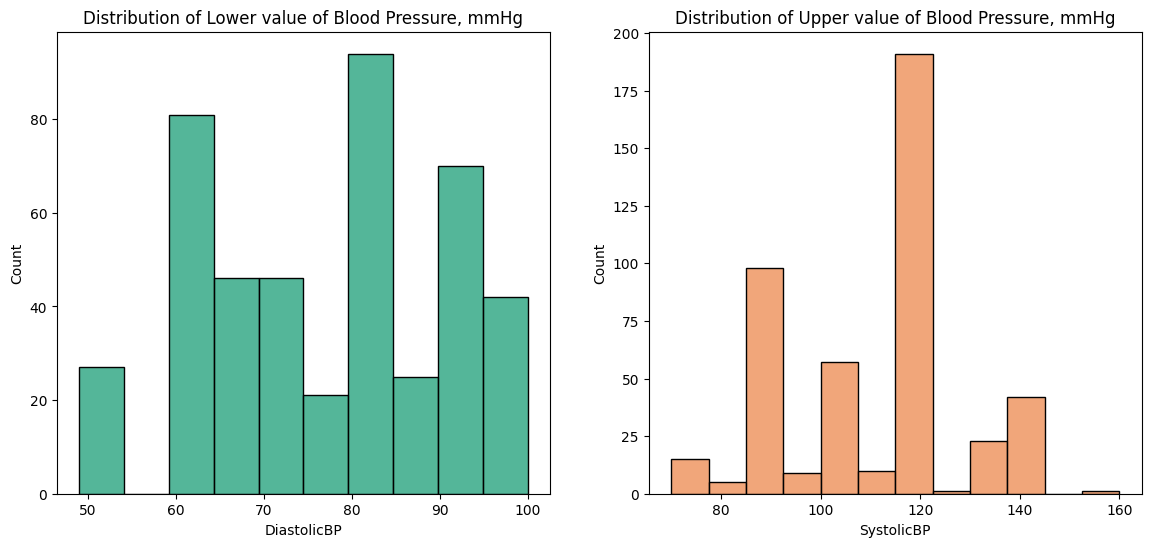

In [20]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(14,6))

sns.histplot(ax=axes[0], x=df.DiastolicBP)
axes[0].set_title("Distribution of Lower value of Blood Pressure, mmHg")

sns.histplot(ax=axes[1], x=df.SystolicBP, color="#ed894e")
axes[1].set_title("Distribution of Upper value of Blood Pressure, mmHg");

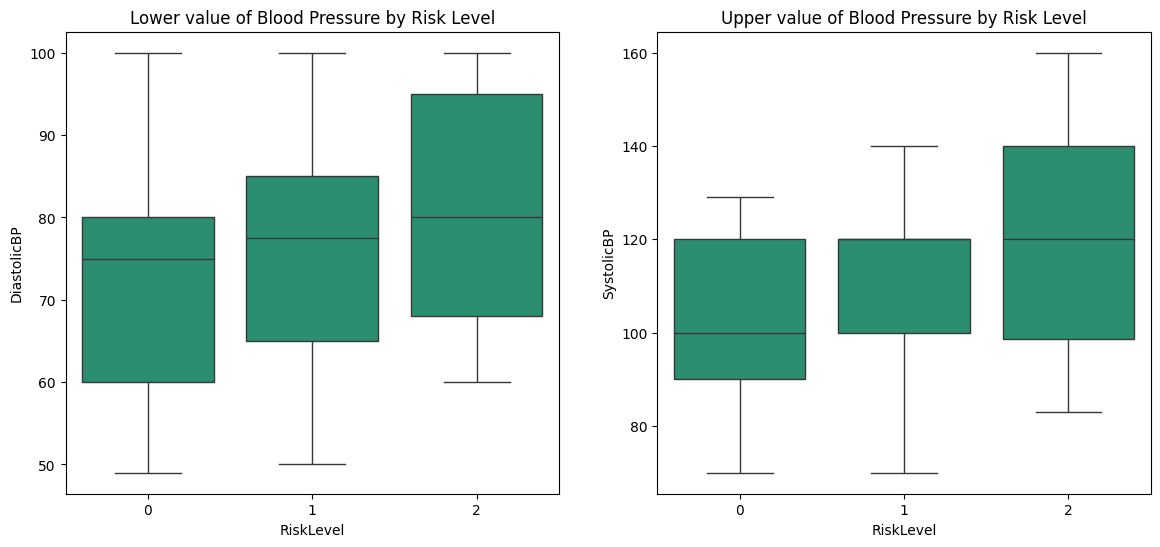

In [21]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(14,6))

sns.boxplot(ax=axes[0], x=df.RiskLevel, y=df.DiastolicBP)
axes[0].set_title("Lower value of Blood Pressure by Risk Level")

sns.boxplot(ax=axes[1], x=df.RiskLevel, y=df.SystolicBP)
axes[1].set_title("Upper value of Blood Pressure by Risk Level");

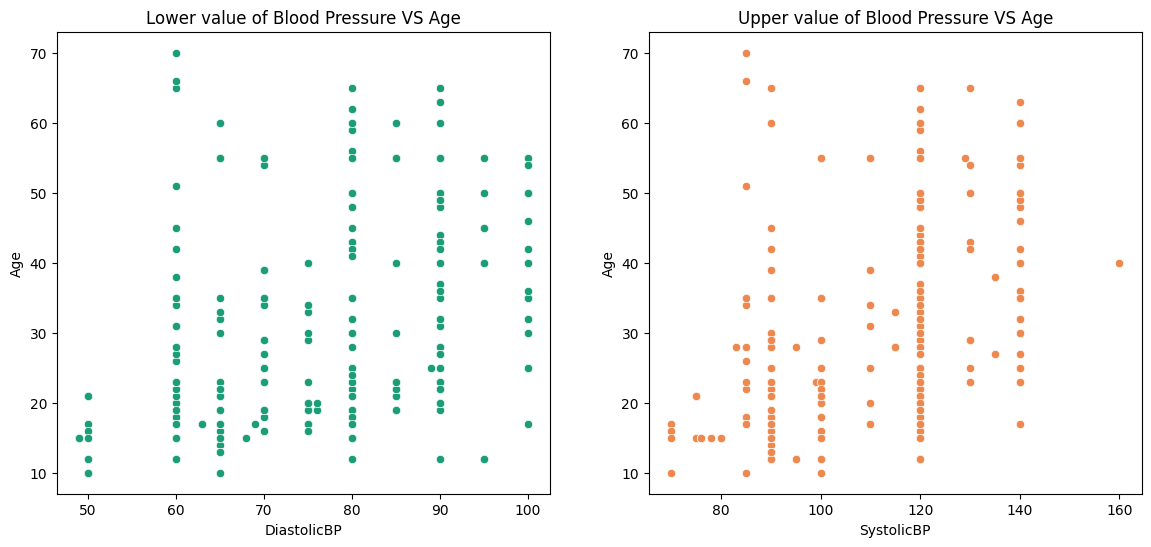

In [22]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(14,6))

sns.scatterplot(x=df.DiastolicBP, y=df.Age, ax=axes[0])
axes[0].set_title("Lower value of Blood Pressure VS Age")

sns.scatterplot(ax=axes[1], x=df.SystolicBP, y=df.Age, color="#ed894e")
axes[1].set_title("Upper value of Blood Pressure VS Age");

Body Temperature

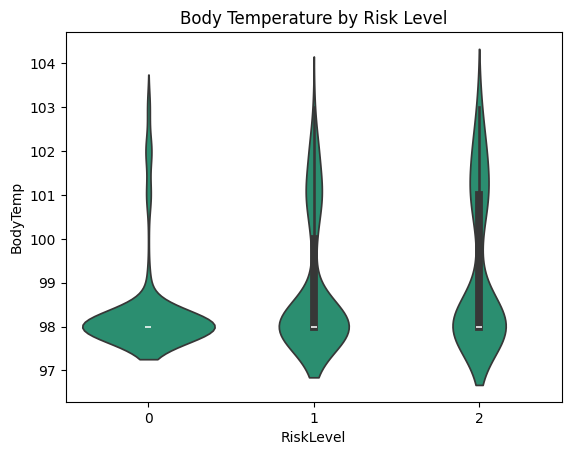

In [23]:
sns.violinplot(y=df.BodyTemp, x=df.RiskLevel).set_title("Body Temperature by Risk Level");

Heart Rate

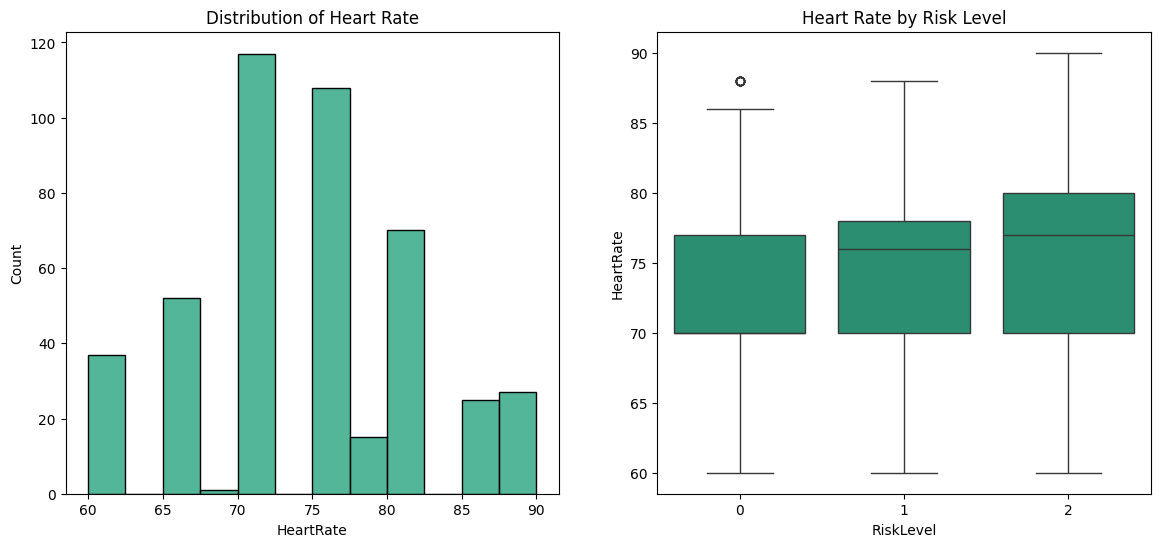

In [25]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(14,6))

sns.histplot(ax=axes[0], x=df.HeartRate)
axes[0].set_title("Distribution of Heart Rate")

sns.boxplot(ax=axes[1], x=df.RiskLevel, y=df.HeartRate)
axes[1].set_title("Heart Rate by Risk Level");

### Observasi dari Visualisasi di atas:

- **Kehamilan dengan risiko rendah** adalah yang paling sering terjadi secara keseluruhan, terjadi pada lebih dari separuh kasus.
- Wanita yang lebih muda cenderung memiliki kehamilan dengan risiko rendah dan sedang, sementara kehamilan pada wanita di atas usia 35 tahun lebih sering diklasifikasikan sebagai risiko tinggi, sehingga memerlukan perhatian lebih.
- Jika seorang wanita hamil memiliki kadar gula darah lebih dari 8 mmol/L, dalam sebagian besar kasus, kehamilan tersebut dianggap berisiko tinggi.
- Distribusi nilai tekanan darah bawah lebih tersebar, sekitar 60-100 mmHg, dibandingkan dengan distribusi nilai tekanan darah atas yang lebih terpusat di sekitar 120 mmHg.
- **Tekanan darah yang lebih tinggi** (baik sistolik maupun diastolik) dan suhu tubuh yang lebih tinggi terkait dengan kehamilan berisiko tinggi.
- Mengenai korelasi antara usia dan tekanan darah, tekanan darah yang sangat rendah (baik sistolik maupun diastolik) terlihat pada beberapa gadis dan wanita muda, tetapi tekanan darah normal dan tinggi tampaknya tidak terlalu berkorelasi dengan usia, setidaknya pada dataset kita.
- **Heart rate** wanita hamil terdistribusi normal dan hanya sedikit terkait dengan tingkat risiko kehamilan.


## Korelasi Fitur

Sangat berguna untuk membangun korelasi antara variabel respon dan variabel prediktor lainnya, karena beberapa di antaranya mungkin tidak memiliki dampak signifikan dalam menentukan tingkat risiko dan tidak akan digunakan dalam analisis. Sekarang, kita akan membuat **heatmap()**, menggunakan library **seaborn**.


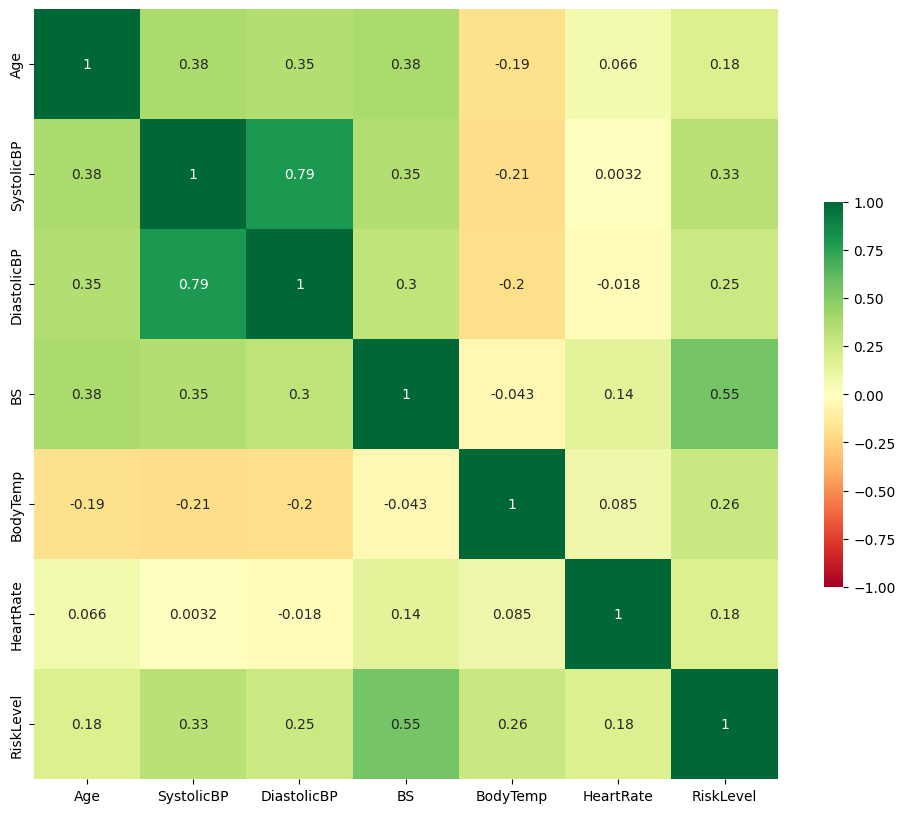

In [26]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(),annot=True,cmap='RdYlGn', vmin=-1, center=0,
           cbar_kws={"shrink": .5})

plt.show()

Dari **heatmap** di atas, **hijau ekstrem** berarti fitur yang sangat berkorelasi positif (hubungan antara dua variabel di mana kedua variabel bergerak dalam arah yang sama), sedangkan **merah ekstrem** berarti fitur yang berkorelasi negatif (hubungan antara dua variabel di mana peningkatan satu variabel dikaitkan dengan penurunan variabel lainnya). Semua variabel tampaknya memiliki korelasi positif dengan variabel respon kita.

Kita dapat melihat bahwa hanya ada satu variabel yang sangat berkorelasi, yaitu **BS (gula darah)**. Variabel lainnya memiliki korelasi positif, tetapi tidak begitu kuat. Jika kita memiliki banyak variabel, kita bisa memilih hanya variabel yang sangat berkorelasi untuk analisis lebih lanjut. Namun, karena kita hanya memiliki 7 kolom, kita akan menggunakan semua variabel tersebut.


## Skew Variabel Transformation

**Skewness** mengacu pada distorsi data atau simetri/asimetri distribusi data. Ketika data Anda terdistorsi (skewed), nilai **mean** dan **median** akan berbeda. **Skewness** melanggar asumsi normalitas pada beberapa model **machine learning**, misalnya **regresi linier**.

Sekarang, kita akan membuat **pairplot** untuk melihat histogram dari setiap kolom, guna memeriksa apakah ada variabel yang terdistorsi.


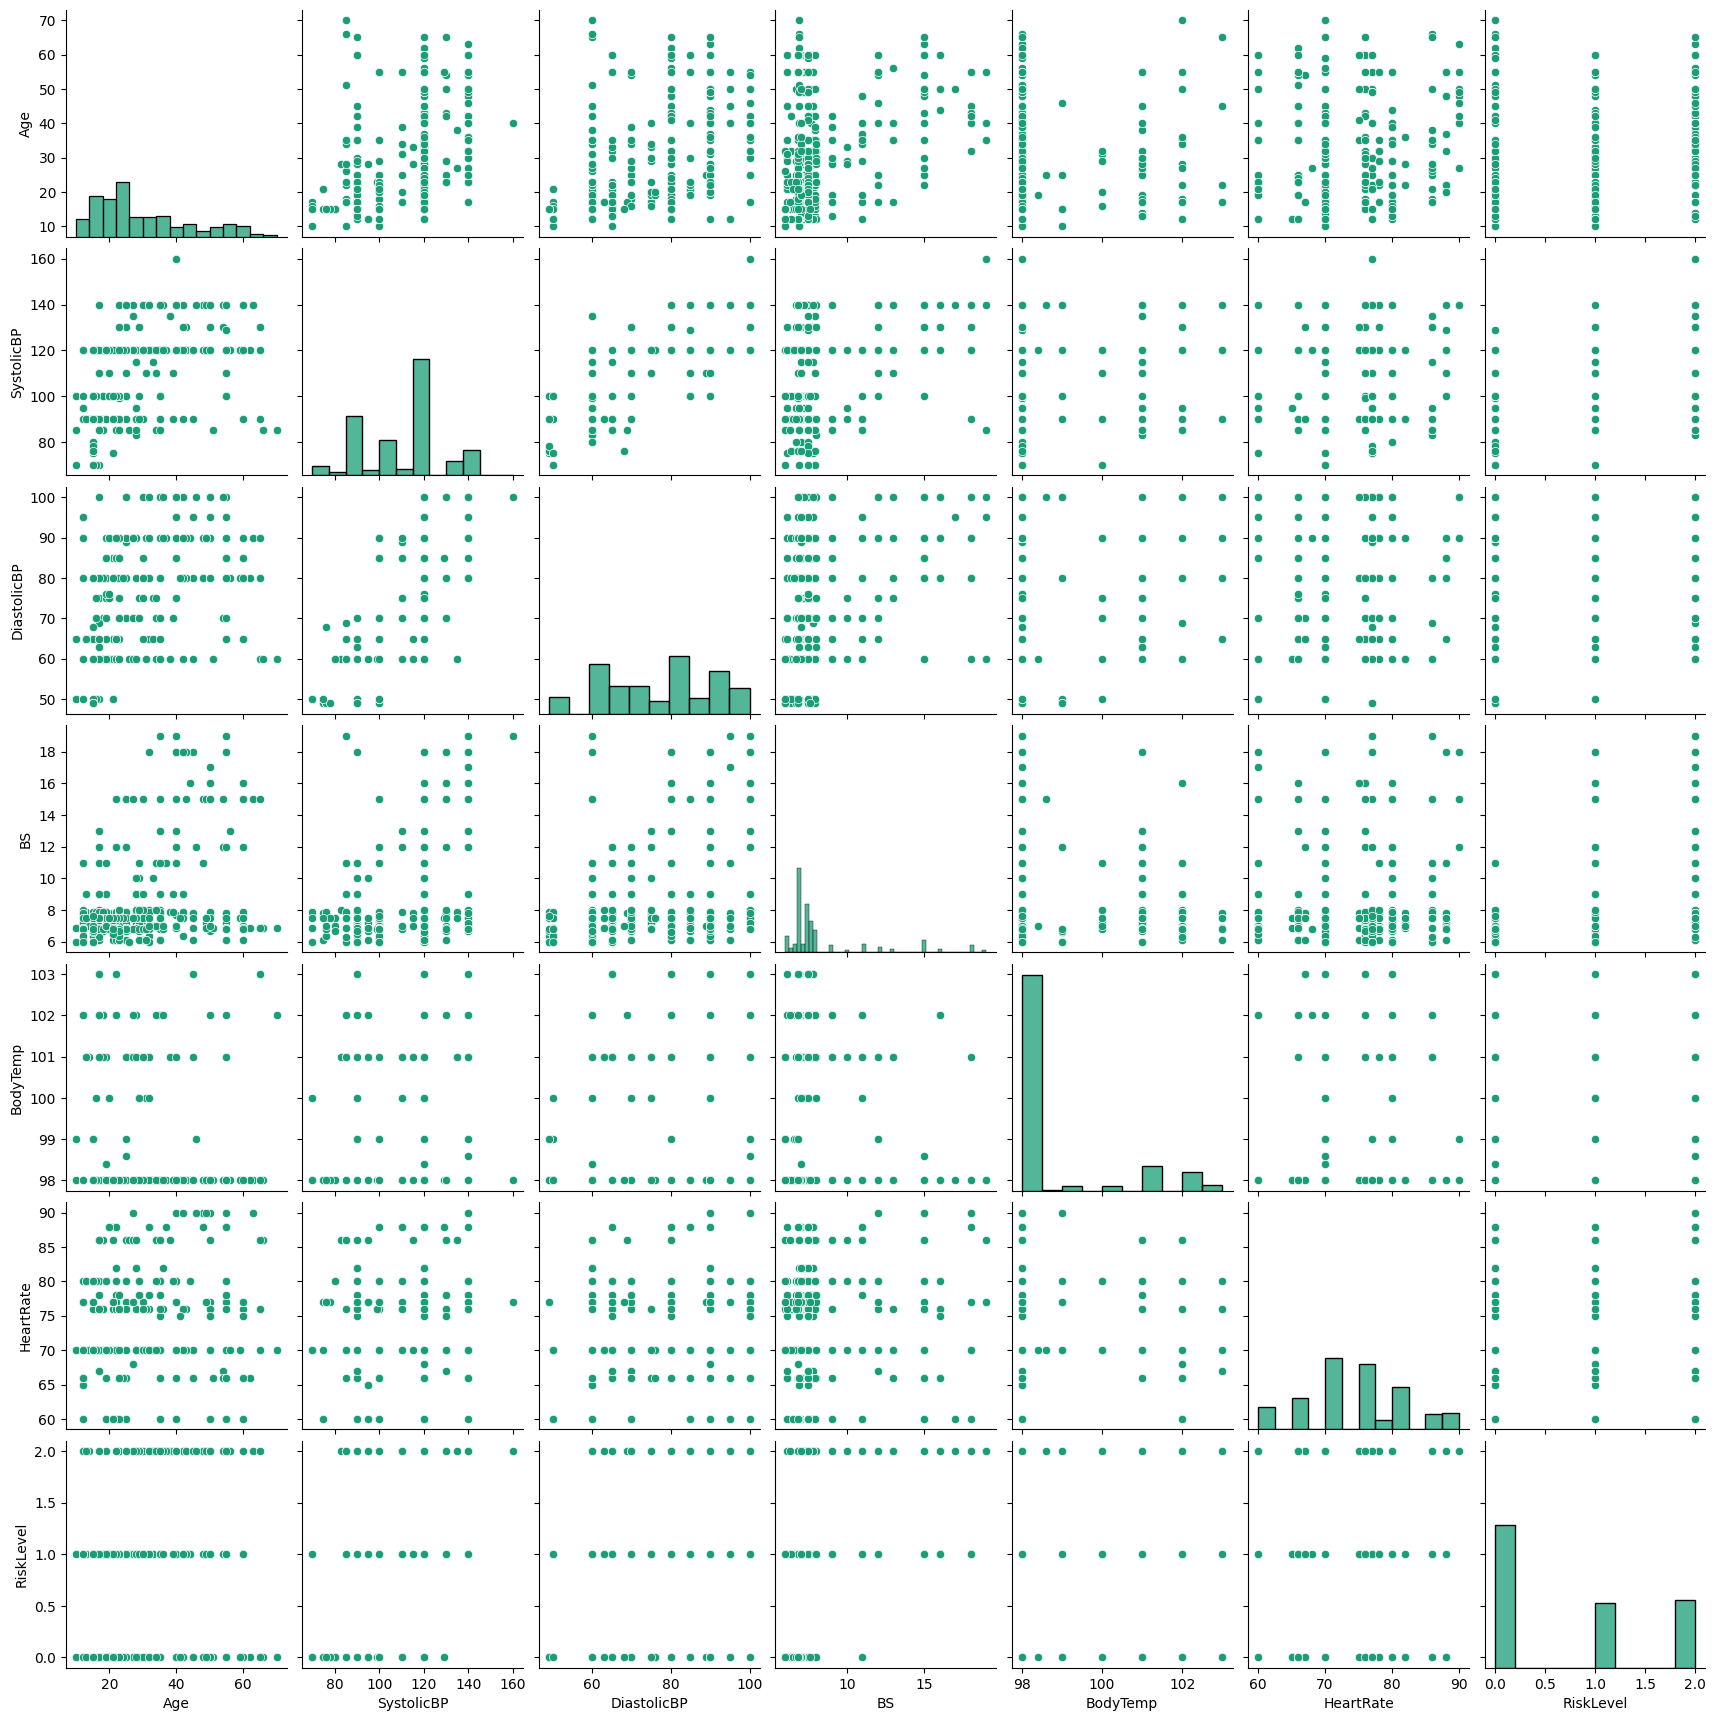

In [27]:
sns.pairplot(df);

Secara visual, tampaknya **BS (gula darah)** dan **BodyTemp (suhu tubuh)** sangat terdistorsi. Keduanya memiliki ekor yang lebih panjang ke kanan, sehingga kita menyebutnya sebagai **skew positif**. Sekarang, mari kita hitung tingkat **skewness** dengan metode `.skew()`.


In [29]:
skew_limit = 0.75 # define a limit above which we will log transform

# Create a list of numerical colums to check for skewing
mask = data.dtypes != object
num_cols = data.columns[mask]

skew_vals = df[num_cols].skew()

In [30]:
# Showing the skewed columns
skew_cols = (skew_vals
             .sort_values(ascending=False)
             .to_frame()
             .rename(columns={0:'Skew'})
             .query('abs(Skew) > {}'.format(skew_limit)))

skew_cols

,Skew
BS,2.262874
BodyTemp,1.751794
Age,0.922079


Rentang **skewness** untuk distribusi berbentuk bel (bell curve) yang cukup simetris adalah antara -0.5 dan 0.5; **skewness** moderat adalah -0.5 hingga -1.0 dan 0.5 hingga 1.0; dan distribusi yang sangat terdistorsi (highly skewed) adalah < -1.0 dan > 1.0. Dalam kasus kita, **skewness** untuk gula darah (~2.26) dan suhu tubuh (~1.75) dianggap sangat terdistorsi. **Skewness** untuk umur adalah sekitar 0.92, yang tergolong skew moderat.

**Catatan**: distribusi kolom **BodyTemp** membuatnya sulit untuk diubah menjadi distribusi normal (sebagian besar baris memiliki nilai yang sama, yaitu nilai minimum dari kolom), jadi kita tidak akan mengubahnya.

Namun, kita bisa mengubah kolom **Blood Sugar** dan **Age**, sehingga mereka terlihat lebih terdistribusi normal. Bergantung pada bentuk distribusinya, kita bisa menggunakan berbagai transformasi umum untuk membuat fitur-fitur tersebut lebih terdistribusi normal:

- **Log**
- **Akar kuadrat (Square Root)**
- **Box-Cox**


0.197419127736239


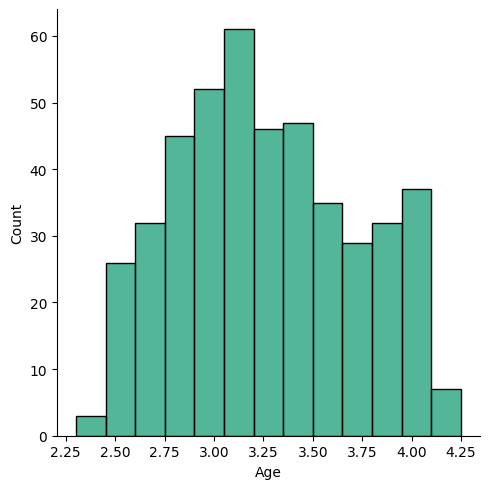

In [31]:
df_transformed = df.copy()

df_transformed["Age"] = df["Age"].apply(np.log)
print(df_transformed["Age"].skew())
sns.displot(df_transformed.Age);

In [32]:
bc_result = boxcox(df.BS)
boxcox_bs = pd.DataFrame(bc_result[0], columns=['BS'])
lambd = bc_result[1]

In [33]:
lambd

-3.3440041657535655

BS    0.264687
dtype: float64


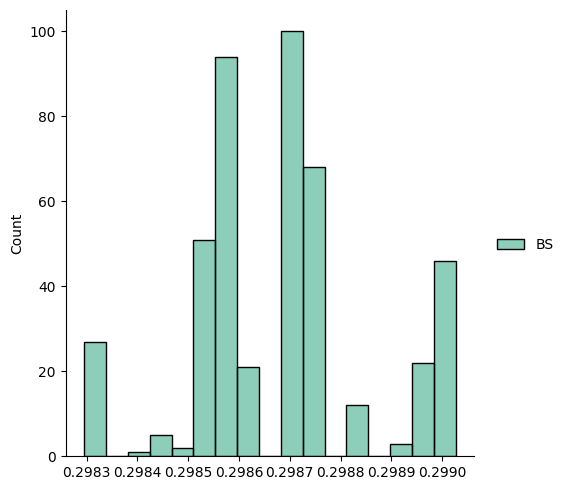

In [34]:
print(boxcox_bs.skew())
sns.displot(boxcox_bs);

In [35]:
df_transformed['BS'] = boxcox_bs['BS']
df_transformed[['BS', 'Age']].skew().to_frame().rename(columns={0:'Skew'}).sort_values('Skew', ascending=False)

,Skew
BS,0.264687
Age,0.197419


Setelah melakukan transformasi **log** dan **Box-Cox**, **skewness** dari:

- **Gula darah** berkurang dari 2.26 menjadi 0.26.
- **Umur** berkurang dari 0.92 menjadi 0.2.

Ini membuat distribusinya menjadi cukup normal.


## Data Preprocessing

### Pisahkan Fitur dan Target

Tetapkan variabel **X** sama dengan fitur numerik dan variabel **y** sama dengan kolom "RiskLevel".


In [37]:
X = df_transformed.drop('RiskLevel', axis=1)
y = df_transformed['RiskLevel']

### Feature Scaling

In [38]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

### Split Data

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=101, stratify=y)

## Modelling

### KNN

In [40]:
error_rate = []

for i in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

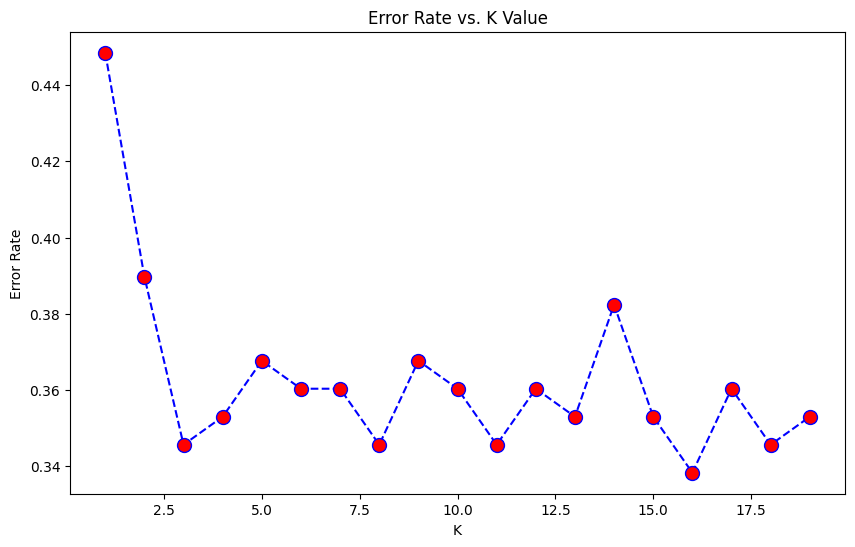

In [41]:
plt.figure(figsize=(10,6))
plt.plot(range(1,20), error_rate, color='blue', linestyle='dashed', marker='o',
        markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate');

In [42]:
knn = KNeighborsClassifier(n_neighbors=16)

knn.fit(X_train,y_train)
knn_preds = knn.predict(X_test)

print('K Nearest Neighbors K=16')
print('\n')
print(confusion_matrix(y_test,knn_preds))
print('\n')
print(classification_report(y_test,knn_preds))

K Nearest Neighbors K=16


[[62  6  2]
 [20  6  6]
 [ 9  3 22]]


              precision    recall  f1-score   support

           0       0.68      0.89      0.77        70
           1       0.40      0.19      0.26        32
           2       0.73      0.65      0.69        34

    accuracy                           0.66       136
   macro avg       0.60      0.57      0.57       136
weighted avg       0.63      0.66      0.63       136



In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# 1. Membuat model Decision Tree dasar
tree = DecisionTreeClassifier(random_state=122)

# 2. Definisikan hyperparameter grid untuk tuning
param_grid = {
    'criterion': ['gini', 'entropy'],         # fungsi pengukuran kualitas split
    'splitter': ['best', 'random'],            # strategi pemilihan split
    'max_depth': [10, 20, 30],                 # kedalaman maksimal tree
    'min_samples_split': [2, 5, 10],           # minimal jumlah samples untuk split
    'min_samples_leaf': [2, 4]                 # minimal jumlah samples di leaf node
}

# 3. Setup GridSearchCV
grid_search_tree = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. Fit Grid Search ke data training
grid_search_tree.fit(X_train, y_train)

# 5. Print best parameters dan best score
print('Best Parameters: ', grid_search_tree.best_params_)
print('Best Cross-Validation Accuracy: ', grid_search_tree.best_score_)

# 6. Gunakan model terbaik untuk prediksi di test set
best_tree = grid_search_tree.best_estimator_

# Prediksi di test set
tree_preds = best_tree.predict(X_test)

# 7. Evaluasi model
print('Decision Tree Performance on Test Set')
print('\n')
print(confusion_matrix(y_test, tree_preds))
print('\n')
print(classification_report(y_test, tree_preds))


Best Parameters:  {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'random'}
Best Cross-Validation Accuracy:  0.709077380952381
Decision Tree Performance on Test Set


[[65  3  2]
 [19  8  5]
 [ 5  8 21]]


              precision    recall  f1-score   support

           0       0.73      0.93      0.82        70
           1       0.42      0.25      0.31        32
           2       0.75      0.62      0.68        34

    accuracy                           0.69       136
   macro avg       0.63      0.60      0.60       136
weighted avg       0.66      0.69      0.66       136



In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Membuat model dasar
logreg = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=5000, random_state=122)

# Definisikan grid hyperparameter
param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],  # regularization strength
    'penalty': ['l1', 'l2'],        # regularization type
}

# Setup GridSearchCV
grid_search_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid_logreg,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit ke training data
grid_search_logreg.fit(X_train, y_train)

# Print hasil terbaik
print('Best Parameters for Logistic Regression:', grid_search_logreg.best_params_)
print('Best Cross-Validation Accuracy:', grid_search_logreg.best_score_)

# Gunakan model terbaik
best_logreg = grid_search_logreg.best_estimator_

# Prediksi di test set
logreg_preds = best_logreg.predict(X_test)

# Evaluasi
print('Logistic Regression Performance on Test Set')
print('\n')
print(confusion_matrix(y_test, logreg_preds))
print('\n')
print(classification_report(y_test, logreg_preds))


Best Parameters for Logistic Regression: {'C': 1, 'penalty': 'l1'}
Best Cross-Validation Accuracy: 0.6865079365079365
Logistic Regression Performance on Test Set


[[67  1  2]
 [21  6  5]
 [ 9  1 24]]


              precision    recall  f1-score   support

           0       0.69      0.96      0.80        70
           1       0.75      0.19      0.30        32
           2       0.77      0.71      0.74        34

    accuracy                           0.71       136
   macro avg       0.74      0.62      0.61       136
weighted avg       0.73      0.71      0.67       136



D:\ML\ENV\envLab1\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [46]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

# Membuat model Gaussian Naive Bayes
nb = GaussianNB()

# Fit ke training data
nb.fit(X_train, y_train)

# Prediksi di test set
nb_preds = nb.predict(X_test)

# Evaluasi
print('Naive Bayes Performance on Test Set')
print('\n')
print(confusion_matrix(y_test, nb_preds))
print('\n')
print(classification_report(y_test, nb_preds))


Naive Bayes Performance on Test Set


[[64  6  0]
 [25  4  3]
 [ 4  7 23]]


              precision    recall  f1-score   support

           0       0.69      0.91      0.79        70
           1       0.24      0.12      0.16        32
           2       0.88      0.68      0.77        34

    accuracy                           0.67       136
   macro avg       0.60      0.57      0.57       136
weighted avg       0.63      0.67      0.63       136



### Kesimpulan dan Perbandingan Model

Berikut adalah hasil perbandingan antara empat model yang diuji untuk klasifikasi risiko kehamilan:

#### 1. **K Nearest Neighbors (K=16)**
- **Akurasi**: 66%
- **Kelebihan**: Model ini menunjukkan kemampuan yang baik dalam mengklasifikasikan kehamilan dengan risiko rendah (kelas 0).
- **Kekurangan**: Kinerja pada kelas 1 (risiko sedang) kurang baik, dengan recall yang rendah (19%).

#### 2. **Decision Tree**
- **Akurasi**: 69%
- **Kelebihan**: Model ini lebih baik dalam mengklasifikasikan kehamilan dengan risiko tinggi (kelas 2), dengan recall sebesar 62%.
- **Kekurangan**: Precision untuk kelas 1 masih rendah (42%), meskipun recall-nya lebih tinggi dibandingkan KNN.

#### 3. **Logistic Regression**
- **Akurasi**: 71%
- **Kelebihan**: Logistic Regression memiliki kemampuan terbaik dalam mengklasifikasikan kehamilan dengan risiko rendah (kelas 0) dan hasil yang seimbang di semua kelas.
- **Kekurangan**: Recall untuk kelas 1 (risiko sedang) cukup rendah (19%), meskipun precision-nya lebih tinggi daripada Naive Bayes.

#### 4. **Naive Bayes**
- **Akurasi**: 67%
- **Kelebihan**: Model ini sangat baik dalam mengklasifikasikan kehamilan dengan risiko tinggi (kelas 2), dengan precision mencapai 88%.
- **Kekurangan**: Model ini sangat buruk dalam mengklasifikasikan kehamilan dengan risiko sedang (kelas 1), dengan recall hanya 12%.

### Perbandingan:

- **Akurasi Tertinggi**: Logistic Regression (71%) menunjukkan performa terbaik secara keseluruhan, dengan keseimbangan yang baik antara precision dan recall di semua kelas.
- **Performa Kelas 0 (Rendah)**: Logistic Regression dan Decision Tree memiliki kemampuan yang baik dalam mengklasifikasikan kehamilan dengan risiko rendah.
- **Performa Kelas 1 (Sedang)**: Semua model mengalami kesulitan dalam mengklasifikasikan kelas 1, namun Logistic Regression lebih baik dibandingkan yang lain.
- **Performa Kelas 2 (Tinggi)**: Naive Bayes memiliki performa yang sangat baik dalam mengklasifikasikan kelas 2, dengan precision tertinggi (88%).

Secara keseluruhan, **Logistic Regression** memberikan keseimbangan terbaik di antara model yang diuji, dengan akurasi tertinggi dan performa yang lebih seimbang di semua kelas. Namun, jika prioritasnya adalah mengidentifikasi risiko tinggi dengan sangat tepat, **Naive Bayes** bisa menjadi pilihan terbaik.
